In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:
def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    task = 'equivariant' if ('dualtask' in path_str or 'equivariant' in path_str) else 'invariant' 
    if 'audioset' in path_str:
        task = 'supervised audioset'

    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
        
    eq_lmbda = ''
    aug_str = ''
    if task == 'equivariant':
        eq_lmbda = ' ' + re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
            aug_str = ' paired augmentations'
        
    test_layer = path.stem.split("_")[-1] # is last name of stem 

    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    return model_name, arch, test_layer, eq_lmbda




## Get ESC 50 results for each model

In [4]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet18_barlow*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str:
        if 'eq_lmbda' in path_str:
            if not path_str.startswith('kell2018'):
                if 'fixed_loss' not in path_str:
                    continue 
                
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [5]:
esc_50_df.model_name.unique()

array(['kell2018 equivariant 1e-1', 'kell2018 invariant',
       'resnet18 equivariant 1e-01', 'resnet18 equivariant 3e-01',
       'resnet18 equivariant 5e-01', 'resnet18 equivariant 2e-01',
       'resnet18 equivariant 4e-01', 'resnet18 equivariant 1e-02',
       'resnet18 equivariant 1', 'resnet18 invariant',
       'resnet18 equivariant 3e-01 paired augmentations',
       'resnet18 supervised audioset', 'resnet50 supervised audioset'],
      dtype=object)

## Get word task results 

In [6]:
def format_model_str_word_task(path):
    path_str = str(path)
    task = 'equivariant' if ('dualtask' in path_str or 'equivariant' in path_str) else 'invariant' 
    if 'audioset' in path_str:
        task = 'supervised audioset'

    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
        
    eq_lmbda = ''
    if task == 'equivariant':
        eq_lmbda = ' ' + re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        
    test_layer = path_str.split('task_')[-1].split('_')[0]
    
    aug_str = ''
    if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
        aug_str = ' paired augmentations'
    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    return model_name, arch, test_layer, eq_lmbda

In [9]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

all_word_task_results = kell2018_word_results + resnet18_word_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)

    if 'kell2018' in path_str:
        if 'eq_lmbda' in path_str:
            if not path_str.startswith('kell2018'):
                if 'fixed_loss' not in path_str:
                    continue 
            
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):
        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}

    # print(test_layer)

    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')


In [10]:
word_df

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem
0,kell2018 invariant,kell2018,relu2,,0.559953,0.000807,0.980157,0.000588
1,kell2018 invariant,kell2018,relu3,,0.511927,0.000829,0.956045,0.000456
2,resnet18 equivariant 5e-01,resnet18,layer3,5e-01,0.494528,0.000833,0.936153,0.000443
3,resnet18 equivariant 1e-01,resnet18,layer2,1e-01,0.514917,0.000815,0.937214,0.000426
4,resnet18 equivariant 3e-01,resnet18,layer2,3e-01,0.523625,0.000832,0.939089,0.000426
5,resnet18 equivariant 3e-01,resnet18,layer3,3e-01,0.519206,0.000822,0.937995,0.000422
6,resnet18 equivariant 3e-01 paired augmentations,resnet18,layer2,3e-01,0.520784,0.000845,0.938471,0.000422
7,resnet18 equivariant 5e-01,resnet18,layer2,5e-01,0.001121,0.000056,0.668512,0.003311
8,resnet18 invariant,resnet18,layer2,,0.001508,0.000063,0.722399,0.002293
9,resnet18 equivariant 4e-01,resnet18,layer3,4e-01,0.496462,0.000831,0.934847,0.000434


In [11]:
df = pd.concat([word_df, esc_50_df], axis=0, ignore_index=True)
df

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,overall_acc
0,kell2018 invariant,kell2018,relu2,,0.559953,0.000807,0.980157,0.000588,NaN
1,kell2018 invariant,kell2018,relu3,,0.511927,0.000829,0.956045,0.000456,NaN
2,resnet18 equivariant 5e-01,resnet18,layer3,5e-01,0.494528,0.000833,0.936153,0.000443,NaN
3,resnet18 equivariant 1e-01,resnet18,layer2,1e-01,0.514917,0.000815,0.937214,0.000426,NaN
4,resnet18 equivariant 3e-01,resnet18,layer2,3e-01,0.523625,0.000832,0.939089,0.000426,NaN
...,...,...,...,...,...,...,...,...,...
139,resnet18 equivariant 1e-02,resnet18,layer2,1e-02,NaN,NaN,NaN,NaN,0.6525
140,resnet18 equivariant 1,resnet18,layer3,1,NaN,NaN,NaN,NaN,0.6350
141,resnet18 equivariant 5e-01,resnet18,layer4,5e-01,NaN,NaN,NaN,NaN,0.6235
142,resnet18 equivariant 4e-01,resnet18,layer2,4e-01,NaN,NaN,NaN,NaN,0.6595


# Plot ESC 50 results

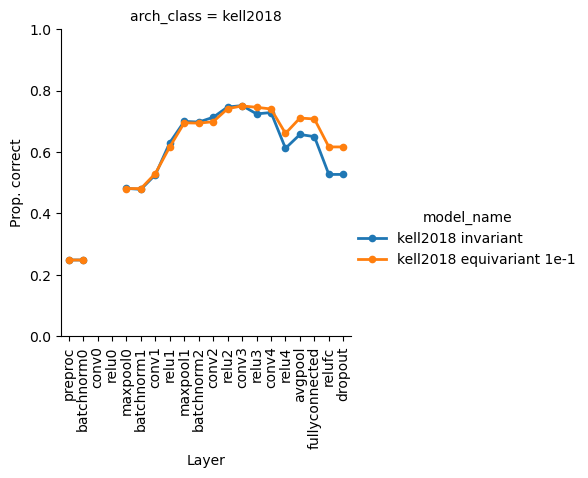

In [12]:
g = sns.catplot(data=df[df.arch_class == 'kell2018'],
                order=test_layers,
                kind='point',
                x='test_layer',
                y='overall_acc',
                col='arch_class',
                hue="model_name",
                height=4,
                lw=2,
                ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

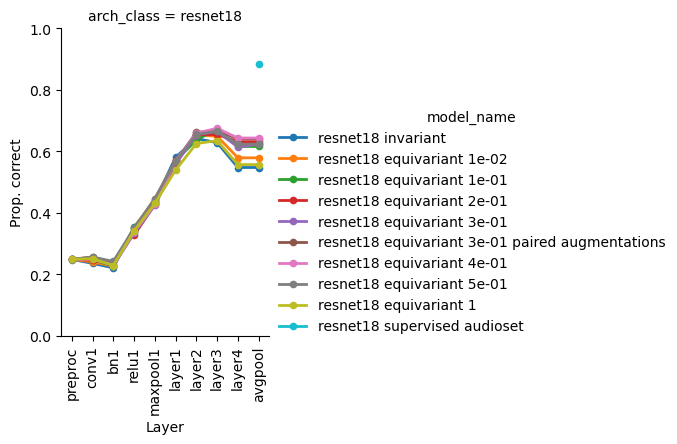

In [14]:
hue_order = [
              'resnet18 invariant',
              'resnet18 equivariant 1e-02',
              'resnet18 equivariant 1e-01',
              'resnet18 equivariant 2e-01',
              'resnet18 equivariant 3e-01',
              'resnet18 equivariant 3e-01 paired augmentations',
              'resnet18 equivariant 4e-01',
              'resnet18 equivariant 5e-01',
              'resnet18 equivariant 1',
              'resnet18 supervised audioset']


# hue_dict = {}
# hue_dict['resnet18 invariant'] = 'k'
# hue_dict['resnet18 supervised audioset'] = 'tab:orange'

# equi_palette = sns.color_palette("crest", n_colors=len(hue_order[1:-1])) 
# equi_color_dict = dict(zip(hue_order[1:-1], equi_palette))

# hue_dict = {**hue_dict, **equi_color_dict}

g = sns.catplot(data=df[df.arch_class == 'resnet18'], 
                order=resnet18_layer_order,
                kind='point', x='test_layer', y='overall_acc', col='arch_class',
                hue="model_name", 
                # palette=hue_dict,
                hue_order=hue_order,
                 height=4, lw=2, ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

/tmp/ipykernel_2097427/4241579863.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(hue_order, rotation=90)
/tmp/ipykernel_2097427/4241579863.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order[:-1], rotation=90)
/tmp/ipykernel_2097427/4241579863.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order[:-1], rotation=90)


[(0.0, 1.0), Text(0, 0.5, 'Word top-5 prop. correct'), Text(0.5, 0, 'Layer')]

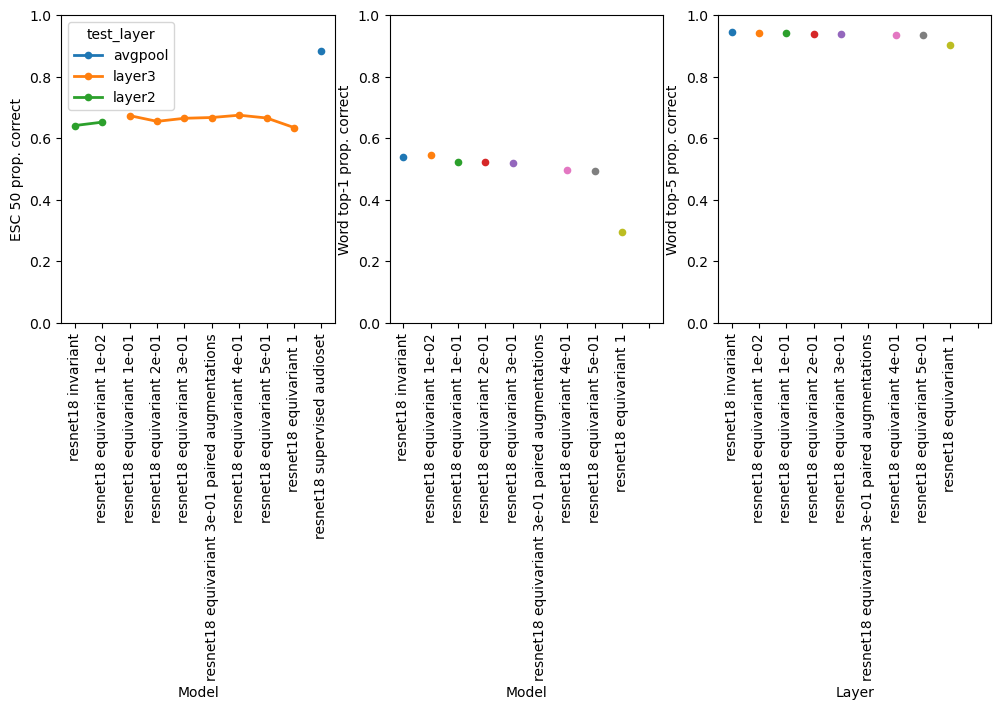

In [17]:
hue_order = [
              'resnet18 invariant',
              'resnet18 equivariant 1e-02',
              'resnet18 equivariant 1e-01',
              'resnet18 equivariant 2e-01',
              'resnet18 equivariant 3e-01',
              'resnet18 equivariant 3e-01 paired augmentations',
              'resnet18 equivariant 4e-01',
              'resnet18 equivariant 5e-01',
              'resnet18 equivariant 1',
              'resnet18 supervised audioset']

test_layer = 'layer3'

# hue_dict = {}
# hue_dict['resnet18 invariant '] = 'k'
# hue_dict['resnet18 supervised audioset '] = 'tab:orange'

# equi_palette = sns.color_palette("crest", n_colors=len(hue_order[1:-1])) 
# equi_color_dict = dict(zip(hue_order[1:-1], equi_palette))

# hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'resnet18') & (~df.overall_acc.isna())]

esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(resnet18_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(12,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=hue_order,
                 x='model_name', y='overall_acc', #col='arch_class',
                  hue="test_layer",
                # palette=hue_dict,
                # hue_order=hue_order,
                ax = axes[0],
                #  height=4, 
                 lw=2, ms=4)
g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0, 1), ylabel='ESC 50 prop. correct', xlabel='Model')

word_to_plot = df[(df.arch_class == 'resnet18') & (df.test_layer==test_layer) & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name', y='word_top1_mean', 
                hue="model_name",
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[1],
                lw=2, ms=4)
g.set_xticklabels(labels=hue_order[:-1], rotation=90)
g.set(ylim=(0, 1), ylabel='Word top-1 prop. correct', xlabel='Model')

word_to_plot = df[(df.arch_class == 'resnet18') & (df.test_layer==test_layer) & (~df.word_top5_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name', y='word_top5_mean', 
                hue="model_name", 
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],

                lw=2, ms=4)
g.set_xticklabels(labels=hue_order[:-1], rotation=90)
g.set(ylim=(0, 1), ylabel='Word top-5 prop. correct', xlabel='Layer')
# plt.tight_layout()

# axes[0].legend(frameon=False, fontsize=7, ncol=1,)

In [19]:
word_to_plot

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem
0,resnet18 equivariant 5e-01,resnet18,layer3,5e-01,0.494528,0.000833,0.936153,0.000443
1,resnet18 equivariant 3e-01,resnet18,layer3,3e-01,0.519206,0.000822,0.937995,0.000422
2,resnet18 equivariant 4e-01,resnet18,layer3,4e-01,0.496462,0.000831,0.934847,0.000434
3,resnet18 equivariant 2e-01,resnet18,layer3,2e-01,0.521587,0.000820,0.940099,0.000407
4,resnet18 equivariant 1e-01,resnet18,layer3,1e-01,0.522205,0.000821,0.940706,0.000408
5,resnet18 equivariant 1e-02,resnet18,layer3,1e-02,0.545373,0.000823,0.943315,0.000405
6,resnet18 equivariant 1,resnet18,layer3,1,0.294810,0.000742,0.904511,0.000556
7,resnet18 invariant,resnet18,layer3,,0.540570,0.000837,0.943778,0.000402


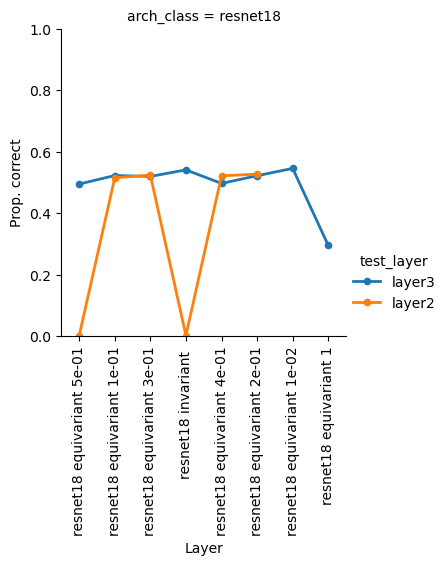

In [90]:
# hue_order = [
#               'resnet18 invariant ',
#               'resnet18 equivariant 1e-02',
#               'resnet18 equivariant 5e-01',
#               'resnet18 equivariant 1',
#             #   'resnet18 supervised audioset '
#               ]
to_plot = df[(df.arch_class == 'resnet18') & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.catplot(data=to_plot,
                # order=hue_order,
                kind='point', x='model_name', y='word_top1_mean', col='arch_class',
                  hue="test_layer", #hue_order=hue_order,
                 height=4, lw=2, ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

/tmp/ipykernel_104698/1845732868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',


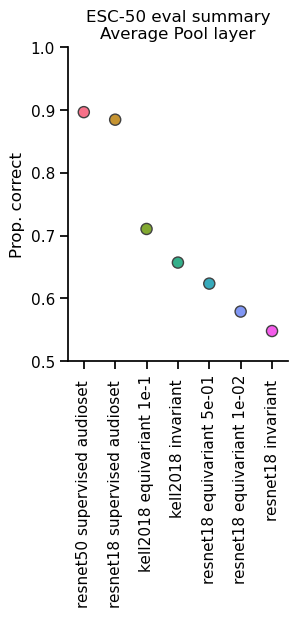

In [55]:

sns.set_context('notebook')
g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                height=4, aspect=1, 
                palette='husl')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nAverage Pool layer', ylim=(.5,1) )


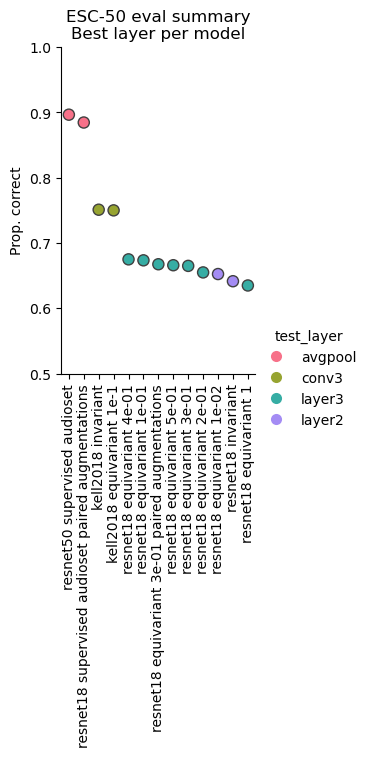

In [87]:
g = sns.catplot(data=df.sort_values('overall_acc', ascending=False).drop_duplicates('model_name'),
                kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                hue='test_layer',
                height=4, aspect=1, 
                palette='husl')
sns.set_context('notebook')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nBest layer per model', ylim=(.5,1) )